In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import ast


In [58]:

data = pd.read_csv('/Users/nicolasroever/Documents/Promotion/Bargaining/bargaining_experiment_analysis/src/template_project/data/DataPilot2_Jeongbin/all_apps_wide-2024-11-12.csv')
termination_times_high_probability = [
    16, 5, 60, 149, 51, 4, 1, 12, 23, 37,
    57, 62, 18, 4, 137, 4, 15, 85, 12, 58,
    2, 27, 16, 9, 6, 26, 10, 12, 87, 7
]

In [70]:
for i in range(4, 34):
    print(data[f'bargain_live.{i}.group.termination_mode'].value_counts())


bargain_live.4.group.termination_mode
Random_Termination    6
Player                2
Name: count, dtype: int64
bargain_live.5.group.termination_mode
Random_Termination    8
Name: count, dtype: int64
bargain_live.6.group.termination_mode
Player    2
Name: count, dtype: int64
bargain_live.7.group.termination_mode
Player    4
Name: count, dtype: int64
bargain_live.8.group.termination_mode
Player    2
Name: count, dtype: int64
bargain_live.9.group.termination_mode
Random_Termination    6
Player                2
Name: count, dtype: int64
bargain_live.10.group.termination_mode
Random_Termination    8
Name: count, dtype: int64
bargain_live.11.group.termination_mode
Random_Termination    6
Name: count, dtype: int64
bargain_live.12.group.termination_mode
Player    2
Name: count, dtype: int64
Series([], Name: count, dtype: int64)
bargain_live.14.group.termination_mode
Player    2
Name: count, dtype: int64
Series([], Name: count, dtype: int64)
bargain_live.16.group.termination_mode
Random_Termin

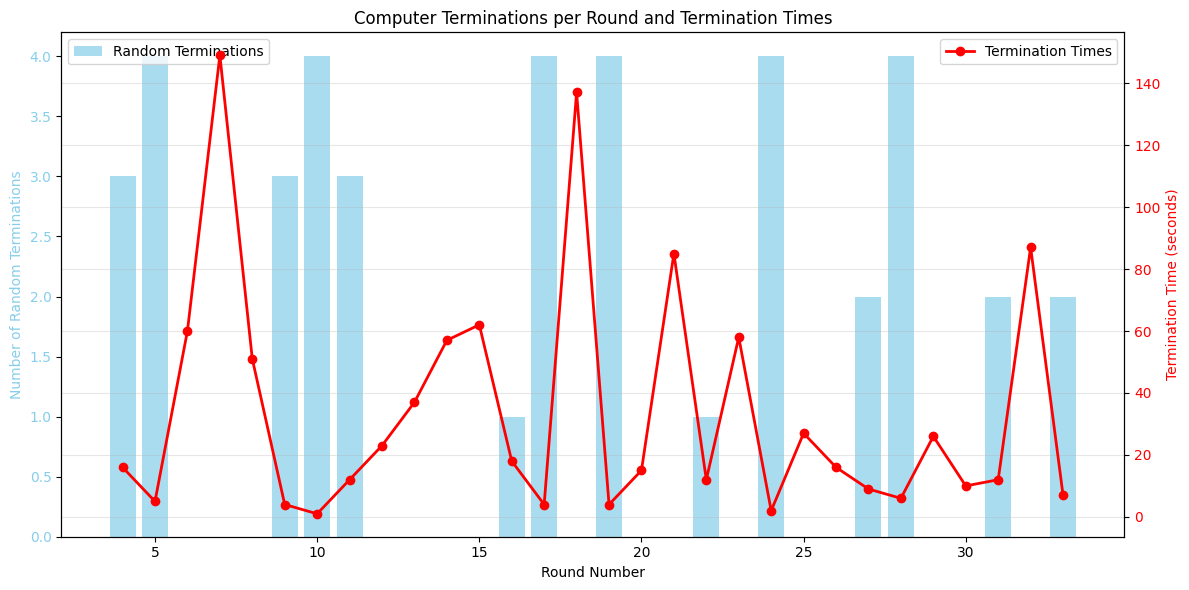

In [76]:
# Create lists to store counts
random_terminations = []
rounds = []

# Count random terminations for each round
for i in range(4, 34):
    counts = data[f'bargain_live.{i}.group.termination_mode'].value_counts()
    if 'Random_Termination' in counts:
        random_terminations.append(counts['Random_Termination'] / 2) 
    else:
        random_terminations.append(0)
    rounds.append(i)

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot random terminations on primary axis
ax1.bar(rounds, random_terminations, color='skyblue', alpha=0.7)
ax1.set_xlabel('Round Number')
ax1.set_ylabel('Number of Random Terminations', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# Create secondary axis
ax2 = ax1.twinx()

# Plot termination times on secondary axis
ax2.plot(rounds, termination_times_high_probability, color='red', linewidth=2, marker='o')
ax2.set_ylabel('Termination Time (seconds)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Computer Terminations per Round and Termination Times')
plt.grid(True, alpha=0.3)

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(['Random Terminations'], loc='upper left')
ax2.legend(['Termination Times'], loc='upper right')

plt.tight_layout()
plt.show()

# Costs


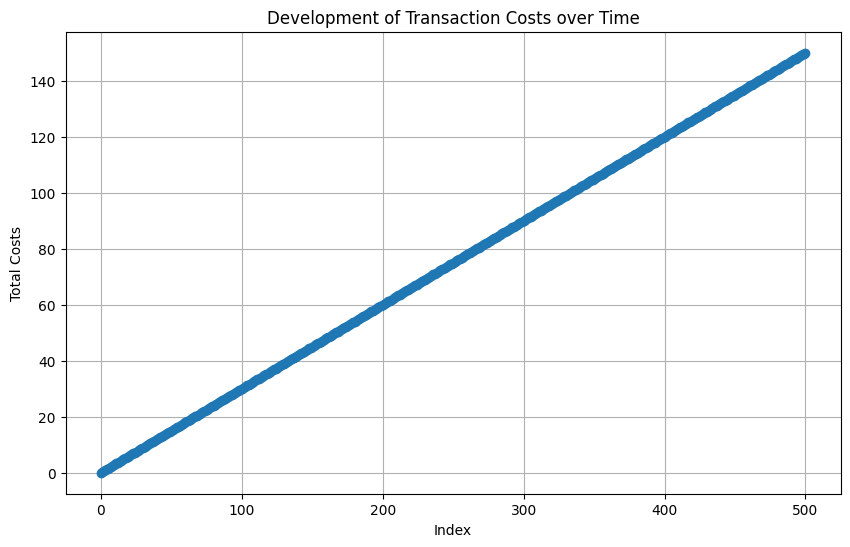

In [89]:
# Extract the total_costs_list and discount_factors_list for player 1 in round 1
player_1_costs = data.loc[0, 'bargain_live.1.player.total_costs_list'] 


# Convert the string representations of the lists to actual lists
player_1_costs_list = ast.literal_eval(player_1_costs)



# Plot 1: Total costs with the index on the x-axis
plt.figure(figsize=(10, 6))
plt.plot(range(len(player_1_costs_list)), player_1_costs_list, marker='o')
plt.xlabel('Index')
plt.ylabel('Total Costs')
plt.title('Development of Transaction Costs over Time')
plt.grid(True)
plt.show()


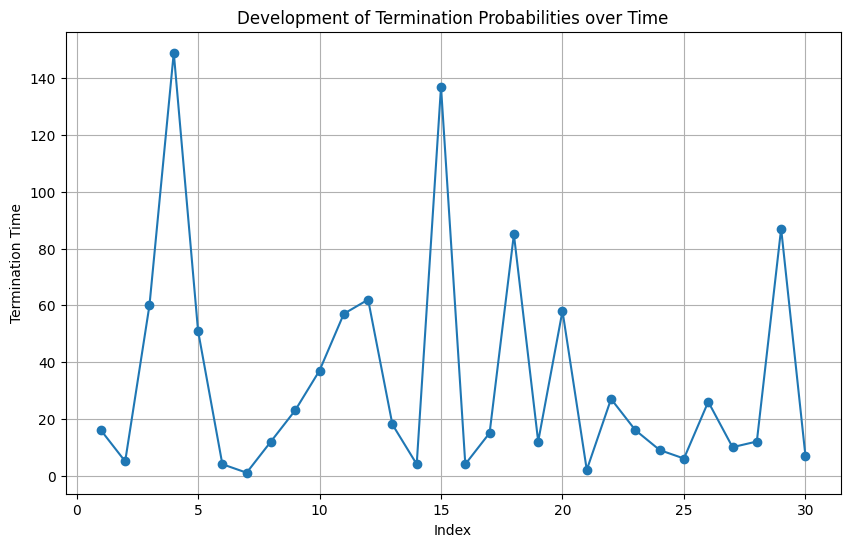

In [60]:

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(termination_times_high_probability) + 1), termination_times_high_probability, marker='o')
plt.xlabel('Index')
plt.ylabel('Termination Time')
plt.title('Development of Termination Probabilities over Time')
plt.grid(True)
plt.show()

## Realized Gains from Trade

In [39]:
# Initialize a list to store gains from trade for each round
gains_from_trade = []

for i in range(4, 33):
    # Calculate gains for buyers
    buyer_gains = data[f'bargain_live.{i}.player.valuation'] - data[f'bargain_live.{i}.group.deal_price']
    buyer_gains[data[f'bargain_live.{i}.player.role'] != 'Buyer'] = pd.NA
    
    # Calculate gains for sellers
    seller_gains = data[f'bargain_live.{i}.group.deal_price'] - data[f'bargain_live.{i}.player.valuation']
    seller_gains[data[f'bargain_live.{i}.player.role'] != 'Seller'] = pd.NA
    
    # Combine gains for both buyers and sellers
    gains = pd.concat([buyer_gains, seller_gains], axis=0).dropna()
    gains_from_trade.append(gains)


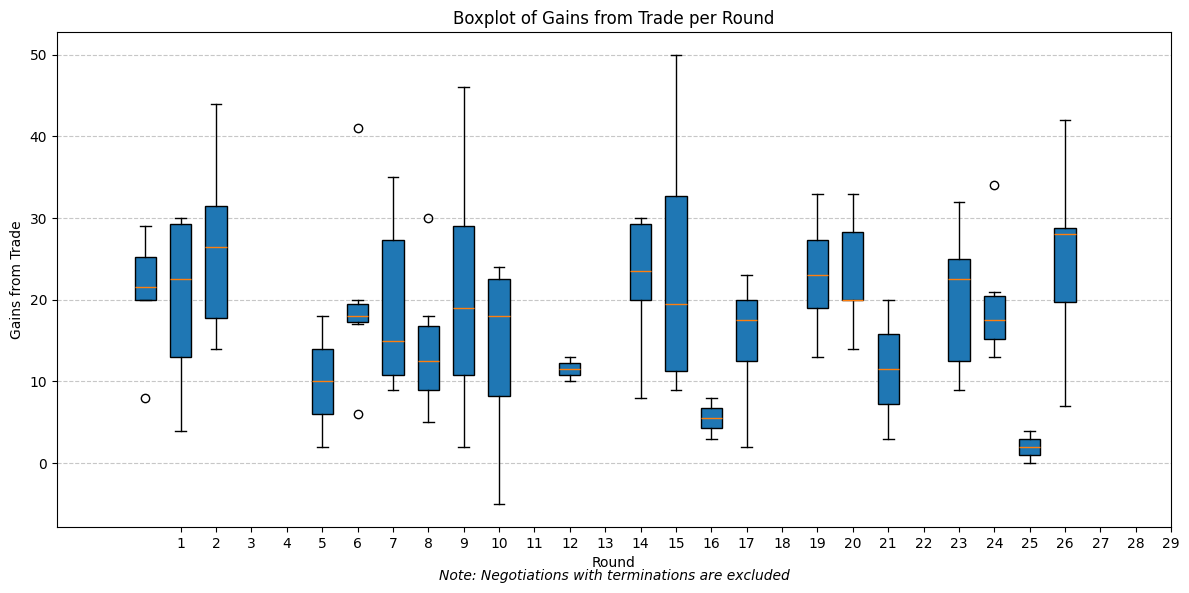

In [40]:
# Create a boxplot of gains from trade for each round
plt.figure(figsize=(12, 6))
plt.boxplot(gains_from_trade, positions=range(1, 30), widths=0.6, patch_artist=True)

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Gains from Trade')
plt.title('Boxplot of Gains from Trade per Round')

# Set x-axis labels to number from 1 to 29
plt.xticks(range(4, 33))

# Add a grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add note about excluded negotiations
plt.text(0.5, -0.1, 'Note: Negotiations with terminations are excluded', 
         ha='center', va='center', transform=plt.gca().transAxes, fontsize=10, style='italic')

# Show the plot
plt.tight_layout()
plt.show()

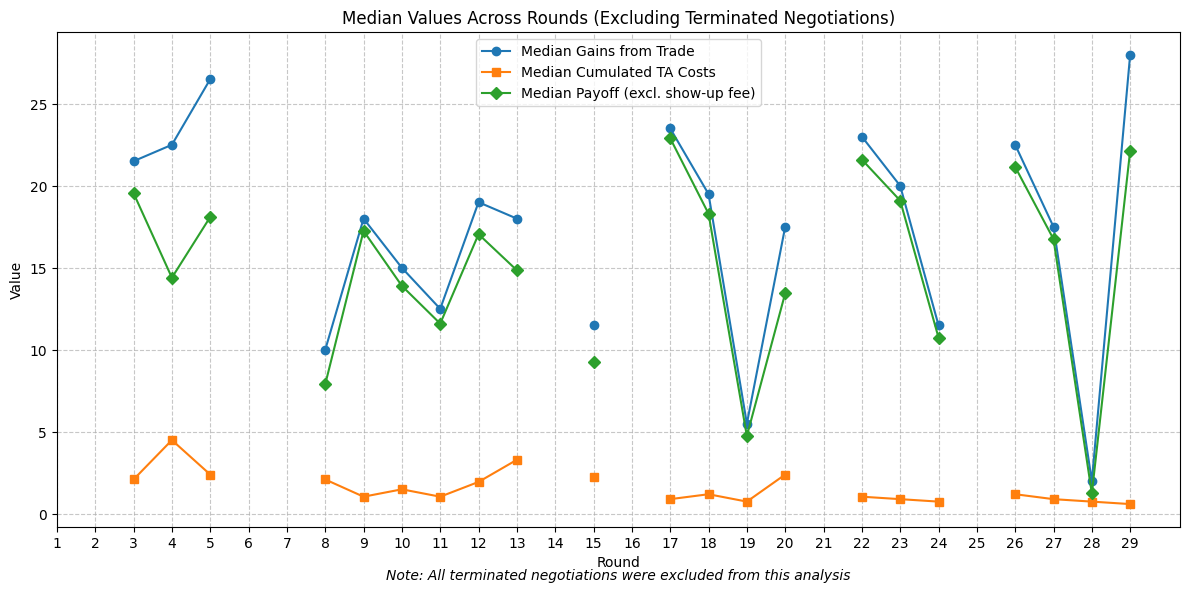

In [41]:
# Calculate gains from trade for each round
gains_from_trade = []
cumulated_TA_costs = []
discounted_gains_from_trade = []
payoffs_excluding_fee = []
payoffs_including_fee = []

for i in range(4, 33):
    # Filter out terminated negotiations
    round_data = data[data[f'bargain_live.{i}.group.terminated'] != 1]
    
    # Calculate gains for buyers and sellers
    buyer_gains = round_data.loc[round_data[f'bargain_live.{i}.player.role'] == 'Buyer', f'bargain_live.{i}.player.valuation'] - round_data.loc[round_data[f'bargain_live.{i}.player.role'] == 'Buyer', f'bargain_live.{i}.group.deal_price']
    seller_gains = round_data.loc[round_data[f'bargain_live.{i}.player.role'] == 'Seller', f'bargain_live.{i}.group.deal_price'] - round_data.loc[round_data[f'bargain_live.{i}.player.role'] == 'Seller', f'bargain_live.{i}.player.valuation']
    gains = pd.concat([buyer_gains, seller_gains])
    gains_from_trade.append(gains.median())
    
    # Calculate cumulated TA costs
    cumulated_TA_costs.append(round_data[f'bargain_live.{i}.player.cumulated_TA_costs'].median())
    
    # Calculate median payoff (excluding show-up fee)
    payoffs_excluding_fee.append(round_data[f'bargain_live.{i}.player.payoff'].median())
    
    # Calculate median payoff (including show-up fee)
    payoffs_including_fee.append((round_data[f'bargain_live.{i}.player.payoff'] + 20).median())

# Create the plot
plt.figure(figsize=(12, 6))

# Plot median gains from trade
plt.plot(range(1, 30), gains_from_trade, marker='o', label='Median Gains from Trade')

# Plot median cumulated TA costs
plt.plot(range(1, 30), cumulated_TA_costs, marker='s', label='Median Cumulated TA Costs')

# Plot median payoff (excluding show-up fee)
plt.plot(range(1, 30), payoffs_excluding_fee, marker='D', label='Median Payoff (excl. show-up fee)')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Value')
plt.title('Median Values Across Rounds (Excluding Terminated Negotiations)')

# Set x-axis labels to number from 1 to 29
plt.xticks(range(1, 30))

# Add a grid for easier reading
plt.grid(axis='both', linestyle='--', alpha=0.7)

# Add legend
plt.legend()

# Add note about excluded negotiations
plt.text(0.5, -0.1, 'Note: All terminated negotiations were excluded from this analysis', 
         ha='center', va='center', transform=plt.gca().transAxes, fontsize=10, style='italic')

# Show the plot
plt.tight_layout()
plt.show()

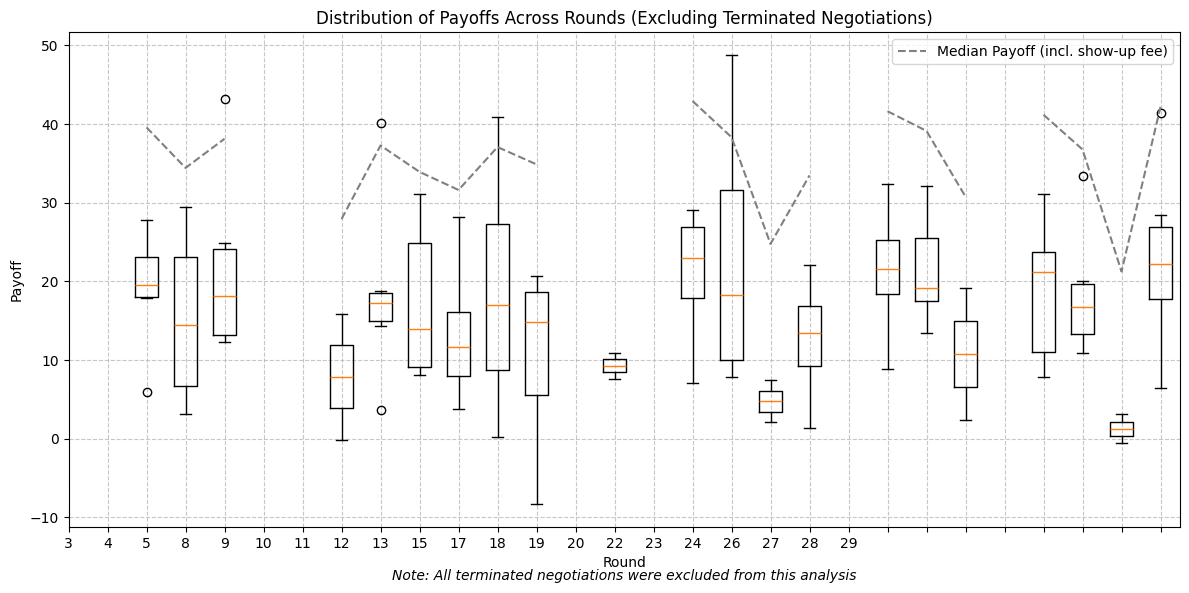

In [80]:
# Calculate payoffs for each round
payoffs_excluding_fee = []
payoffs_including_fee = []

for i in range(4, 33):
    # Filter out terminated negotiations
    round_data = data[data[f'bargain_live.{i}.group.terminated'] != 1]
    
    # Calculate payoff (excluding show-up fee)
    round_payoffs = round_data[f'bargain_live.{i}.player.payoff'].values
    payoffs_excluding_fee.append(round_payoffs)
    
    # Calculate payoff (including show-up fee)
    payoffs_including_fee.append((round_data[f'bargain_live.{i}.player.payoff'] + 20).median())

# Create the plot
plt.figure(figsize=(12, 6))

# Create boxplot for payoffs excluding show-up fee
# Filter out empty arrays and create boxplot directly
non_empty_payoffs = [p for p in payoffs_excluding_fee if len(p) > 0]
positions = [i for i, p in enumerate(payoffs_excluding_fee, 1) if len(p) > 0]

plt.boxplot(non_empty_payoffs, positions=positions, widths=0.6)

# Plot median payoff including show-up fee
plt.plot(range(1, 30), payoffs_including_fee, color='grey', linestyle='--', 
         label='Median Payoff (incl. show-up fee)')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Payoff')
plt.title('Distribution of Payoffs Across Rounds (Excluding Terminated Negotiations)')

# Set x-axis labels
plt.xticks(range(1, 30))

# Add a grid for easier reading
plt.grid(axis='both', linestyle='--', alpha=0.7)

# Add legend
plt.legend()

# Add note about excluded negotiations
plt.text(0.5, -0.1, 'Note: All terminated negotiations were excluded from this analysis', 
         ha='center', va='center', transform=plt.gca().transAxes, fontsize=10, style='italic')

plt.tight_layout()
plt.show()

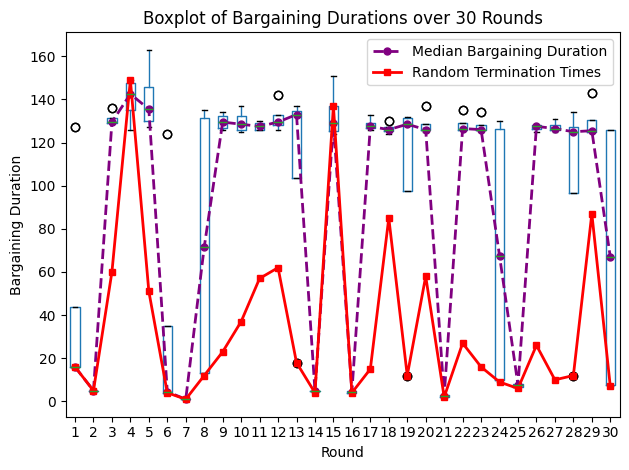

In [64]:
# Extract all bargaining_duration columns for the 29 rounds
bargaining_duration_columns = [f'bargain_live.{i}.group.bargaining_duration' for i in range(4, 34)]

# Filter the relevant data (bargaining durations for 29 rounds)
bargaining_durations = data[bargaining_duration_columns]

# Replace NaN values with 0 (if necessary)
bargaining_durations = bargaining_durations.fillna(0)

# Create a boxplot for each round
boxplot_bargaining_duration = bargaining_durations.boxplot(column=bargaining_duration_columns, grid=False)

# Draw a line through the medians
medians_bargaining_duration = bargaining_durations.median()
plt.plot(range(1, 31), medians_bargaining_duration, color='purple', marker='o', linestyle='dashed', linewidth=2, markersize=5, label='Median Bargaining Duration')

# Add termination times line
plt.plot(range(1, 31), termination_times_high_probability, color='red', marker='s', linestyle='solid', linewidth=2, markersize=5, label='Random Termination Times')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Bargaining Duration')
plt.title('Boxplot of Bargaining Durations over 30 Rounds')

# Set x-axis labels to number from 1 to 29
boxplot_bargaining_duration.set_xticklabels(range(1, 31))

# Add legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

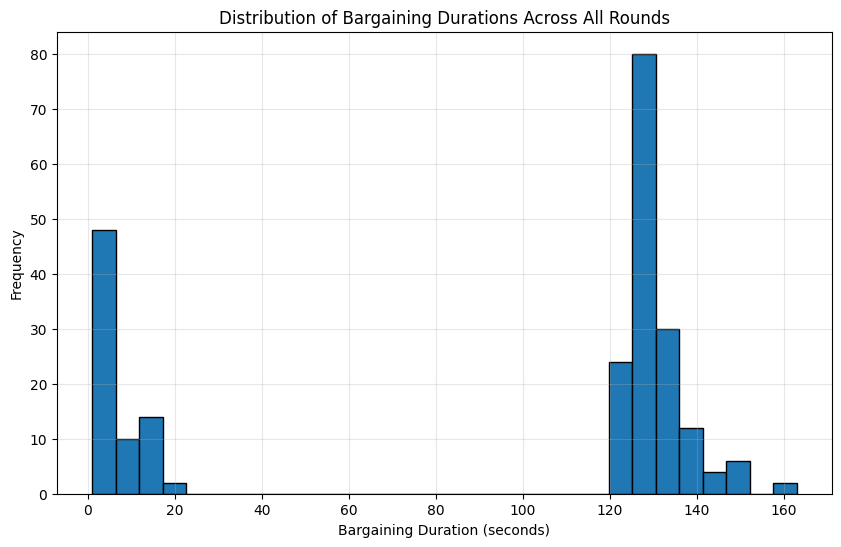

In [44]:
# Extract all bargaining durations into a single series
all_durations = []
for i in range(4, 33):
    durations = data[f'bargain_live.{i}.group.bargaining_duration'].dropna()
    all_durations.extend(durations)

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(all_durations, bins=30, edgecolor='black')
plt.xlabel('Bargaining Duration (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Bargaining Durations Across All Rounds')
plt.grid(True, alpha=0.3)
plt.show()

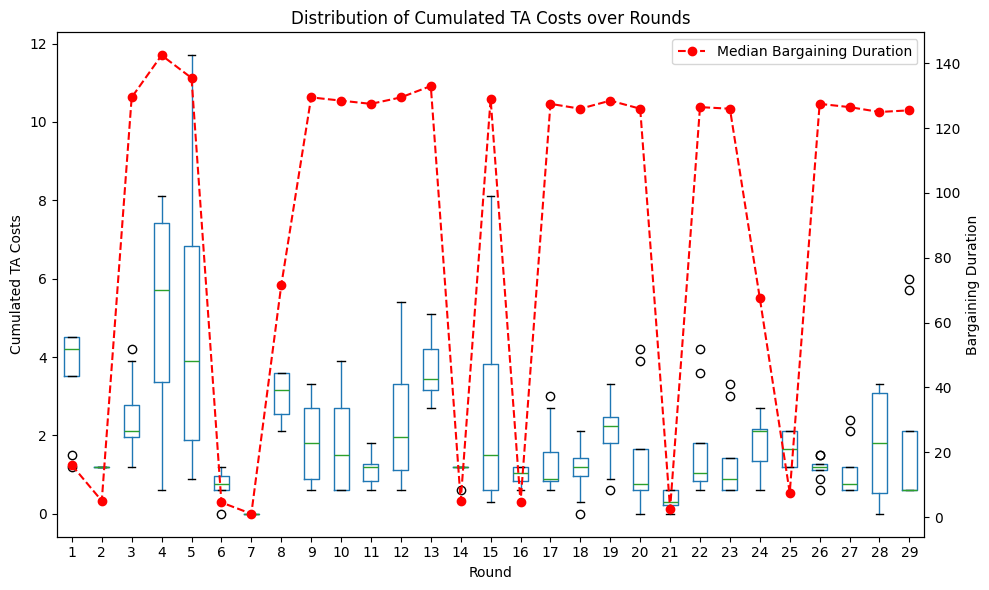

In [86]:
# Extract all cumulated_TA_costs columns for the 20 rounds
cumulated_TA_costs_columns = [f'bargain_live.{i}.player.cumulated_TA_costs' for i in range(4, 33)]

# Filter the relevant data (cumulated TA costs for 20 rounds)
cumulated_TA_costs = data[cumulated_TA_costs_columns]

# Drop NA values
cumulated_TA_costs = cumulated_TA_costs.dropna()

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot boxplot on primary axis
cumulated_TA_costs.boxplot(column=cumulated_TA_costs_columns, grid=False, ax=ax1)

# Calculate median bargaining duration for each round
bargaining_duration_columns = [f'bargain_live.{i}.group.bargaining_duration' for i in range(4, 33)]
bargaining_durations = data[bargaining_duration_columns]
median_durations = bargaining_durations.median()

# Create secondary axis
ax2 = ax1.twinx()

# Plot median bargaining duration line on secondary axis
ax2.plot(range(1, 30), median_durations, color='red', marker='o', linestyle='--', label='Median Bargaining Duration')

# Set labels and title
ax1.set_xlabel('Round')
ax1.set_ylabel('Cumulated TA Costs')
ax2.set_ylabel('Bargaining Duration')
plt.title('Distribution of Cumulated TA Costs over Rounds')

# Set x-axis labels to number from 1 to 29
ax1.set_xticks(range(1, 30))
ax1.set_xticklabels(range(1, 30))

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2)

# Show the plot
plt.tight_layout()
plt.show()

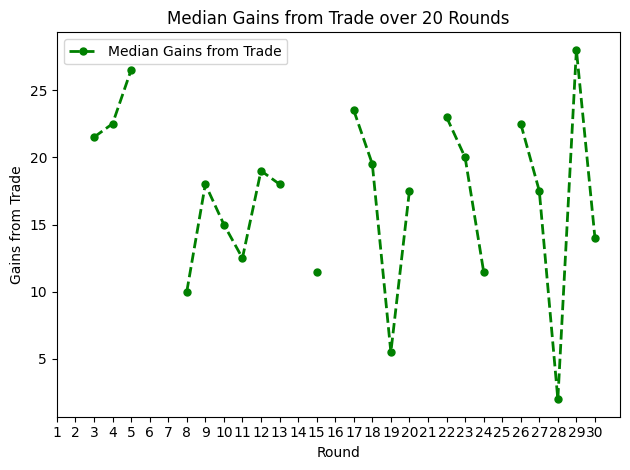

In [46]:
# Calculate gains from trade for each round
gains_from_trade = []
for i in range(4, 34):
    buyer_gains = data.loc[data[f'bargain_live.{i}.player.role'] == 'Buyer', f'bargain_live.{i}.player.valuation'] - data.loc[data[f'bargain_live.{i}.player.role'] == 'Buyer', f'bargain_live.{i}.group.deal_price']
    seller_gains = data.loc[data[f'bargain_live.{i}.player.role'] == 'Seller', f'bargain_live.{i}.group.deal_price'] - data.loc[data[f'bargain_live.{i}.player.role'] == 'Seller', f'bargain_live.{i}.player.valuation']
    gains_from_trade.append(pd.concat([buyer_gains, seller_gains]))

# Concatenate all rounds and calculate median gains from trade
gains_from_trade_df = pd.concat(gains_from_trade, axis=1)
medians_gains_from_trade = gains_from_trade_df.median(axis=0)

# Plot the median gains from trade
plt.plot(range(1, 31), medians_gains_from_trade, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=5, label='Median Gains from Trade')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Gains from Trade')
plt.title('Median Gains from Trade over 20 Rounds')

# Set x-axis labels to number from 1 to 20
plt.xticks(range(1, 31))

# Add legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

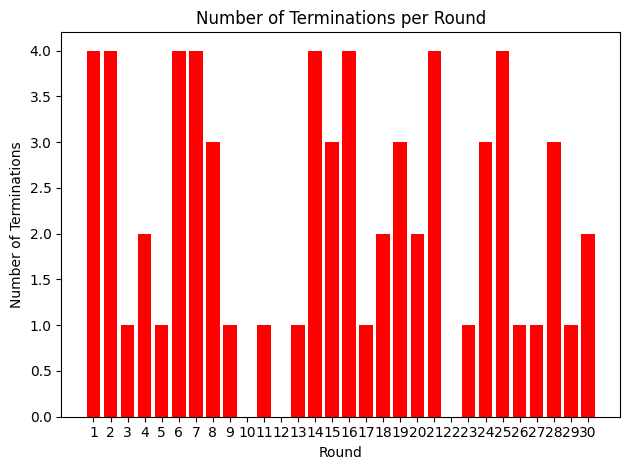

In [47]:
# Extract all terminated columns for the 20 rounds
terminated_columns = [f'bargain_live.{i}.group.terminated' for i in range(4, 34)]

# Filter the relevant data (termination status for 20 rounds)
terminated_data = data[terminated_columns]

# Count the number of terminations per round and divide by 2
terminations_per_round = terminated_data.sum() / 2

# Create a bar plot for terminations per round
plt.bar(range(1, 31), terminations_per_round, color='red')

# Add labels and title
plt.xlabel('Round')
plt.ylabel('Number of Terminations')
plt.title('Number of Terminations per Round')

# Set x-axis labels to number from 1 to 20
plt.xticks(range(1, 31))

# Show the plot
plt.tight_layout()
plt.show()